<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec06_numpy_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/assets/banner.jpg" alt="五点七边 Logo" width="900"/>
</p>

NumPy简介3 - 转置、矩阵乘法
==============


In [ ]:
# @title 辅助函数：读取、展示图片、视频
import numpy as np
from PIL import Image
from IPython.display import display, Image as IPythonImage
import imageio
import io
try:
    from moviepy.editor import VideoFileClip
except ModuleNotFoundError:
    from moviepy import VideoFileClip

# 下载素材
!wget -q --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/Clark.jpg
!wget -q --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/ClarkFalling.mp4
!wget -q --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/playing_cards_grid_4x13_w3900.jpg


def read_image(path="downloads/Clark.jpg"):
    img = Image.open(path)
    return np.asarray(img).copy()


def display_image(img):
    display(Image.fromarray(img))


def read_video(video_path="downloads/ClarkFalling.mp4", trim_end=0.1):
    with VideoFileClip(str(video_path)) as clip:
        fps = clip.fps
        safe_duration = max(0, clip.duration - trim_end)
        nframes = int(safe_duration * fps)

        frames = []
        for i in range(nframes):
            t = i / fps
            frames.append(clip.get_frame(t))

        video = np.stack(frames, axis=0)
    return video


def display_video_as_gif(video, fps=20, loop=0):
    buf = io.BytesIO()
    imageio.mimsave(buf, video, format="gif", fps=fps, loop=loop)
    display(IPythonImage(data=buf.getvalue(), format="gif"))


# 第八章：转置操作


## 8.1 .T

In [ ]:
# 高维数组.T
x = np.random.rand(2, 3, 4, 5)

print(f"{x.shape   = }")
print(f"{x.T.shape = }")

In [ ]:
# 二维矩阵.T
a = np.arange(6).reshape(2, 3)

print(f"{a.shape=}")
print(f"{a.T.shape=}")

## 8.2 transpose()

### 8.2.1 `a.T` = `a.transpose()` = `np.transpose(a)`

In [ ]:
a = np.arange(6).reshape(2, 3)

b = a.T
c = a.transpose()
d = np.transpose(a)

print(f"{b=}")
print(f"{c=}")
print(f"{d=}")

### 8.2.2 传入 `axes` 参数，指定重排方式
<details>
<summary>查看解释</summary>

原数组`video_nhwc`:
| 维度（axis） | axis=0        | axis=1       | axis=2      | axis=3        |
| -------- | ------------- | ------------ | ----------- | ------------- |
| **size** | 32             | 1080            | 1920           | 3             |
| **语义** | N (批/时间)             | H (高)            | W (宽)           | C (通道)             |

新数组`video_nchw`:
| 新数组维度           | axis=0     | axis=1 | axis=2 | axis=3 |
| --------------- | ---------- | ------ | ------ | ------ |
| **来自原数组的 axis** | 0          | 3      | 1      | 2      |
| **原始 size**     | 32          | 3      | 1080      | 1920      |
| **转置后语义**       | N (批/时间)           | C (通道)      | H (高)      | W (宽)      |

<br/>


**总结: `np.transpose()`中`axes`规则:**

- `axes[i]` 表示：新数组的第 `i` 个 `axis`，来自原数组的哪个 `axis`。

</details>

In [ ]:
video_nhwc = np.random.rand(32, 1080, 1920, 3)            # (N, H, W, C)
print(f"{video_nhwc.shape=}")

video_nchw = np.transpose(video_nhwc, axes=(0, 3, 1, 2))  # (N, C, H, W)
print(f"{video_nchw.shape=}")

## 8.3 思考题

<img src="https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/playing_cards_grid_4x13_w3900.jpg"/>

如何将这张图片☝️转换为视频👇：

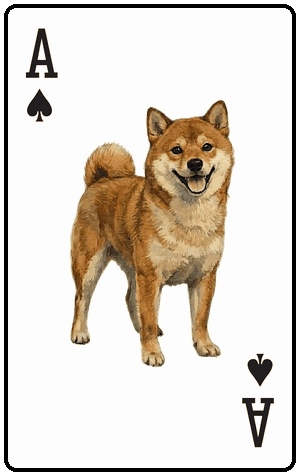


In [ ]:
# 读取图片:
img = read_image("downloads/playing_cards_grid_4x13_w3900.jpg")
print(f"{img.shape=}")
display_image(img)

In [ ]:
# Reshape: (H, W, C) -> (4, card_h, 13, card_w, C)
H, W, C = img.shape
card_h = H // 4
card_w = W // 13

cards = img.reshape(4, card_h, 13, card_w, C)

print(f"{cards.shape=}")

In [ ]:
# Transpose: (4, 13, card_h, card_w, C)
cards_transposed = cards.transpose(0, 2, 1, 3, 4)
print(f"{cards_transposed.shape=}")

In [ ]:
# Reshape: (T, H, W, C)
video = cards_transposed.reshape(-1, card_h, card_w, C)
print(f"{video.shape=}")
display_video_as_gif(video, fps=5)

**再想两个问题：**

- 为什么要 `img.reshape(4, card_h, 13, card_w, C)`，而不是 `(card_h, 4, card_w, 13, C)`？
- 为什么 `transpose` 要用 `cards.transpose(0, 2, 1, 3, 4)`，而不是 `(2, 0, 1, 3, 4)`？

它们其实都在问：维度顺序到底意味着什么？

<details>
<summary>查看提示</summary>
    
**ndarray内存模型小结:**
- 越靠近后面的维度，其元素在内存中通常也越相邻。
- 越靠近前面的维度，越会形成一个更大的块，并且在内存中块与块之间的间距也会更大。
- (前提: Numpy 默认使用 C-order 内存布局)

</details>

## 8.4 维度调整：`swapaxes()` / `moveaxis()`

### 8.4.1 `swapaxes()`: 只交换两个 axis。


In [ ]:
img = read_image()
img_swapped = np.swapaxes(img, 0, 1)  # 交换 H, W

print(f"img.shape        ={img.shape}")
print(f"img_swapped.shape={img_swapped.shape}")

display_image(img_swapped)

### 8.4.2 `moveaxis()`: 把一个 axis 移到新位置

In [ ]:
video_nhwc = np.random.rand(32, 1080, 1920, 3)  # (N,H,W,C)
video_nchw = np.moveaxis(video_nhwc, 3, 1)      # (N,C,H,W)

print(f"{video_nhwc.shape=}")
print(f"{video_nchw.shape=}")

---
# 第九章：矩阵乘法（@ / np.matmul）

## 9.1 二维矩阵：传统矩阵乘法

**矩阵乘法规则**

- $C = A \cdot B$
- $C[i, j] = A[i, :] \cdot B[:, j]$
  - `A的第i行`与`B的第j列`做内积

<video controls playsinline style="width:100%; height:auto;" src="..."></video>

**形状变化**

- $A: (m, n)$  
- $B: (n, p)$  
- $C: (m, p)$


In [ ]:
A = np.arange(6).reshape(2, 3)
B = np.arange(12).reshape(3, 4)

C = A @ B  # @ 表示矩阵乘法

print(f"{A.shape=}")
print(f"{B.shape=}")
print(f"{C.shape=}")

In [ ]:
print(f"{A=}")
print(f"{B=}")
print(f"{C=}")

## 9.2 高维矩阵：batch 维度广播 + 最后两维矩阵乘法

In [ ]:
X = np.random.rand(5, 3, 2)
Y = np.random.rand(5, 2, 4)

Z = X @ Y  # 计算什么呢?

print(f"{Z.shape=}")

<video controls playsinline style="width:100%; height:auto;" src="..."></video>


In [ ]:
X = np.random.rand(6, 5, 4,         3, 2)
Y = np.random.rand(6, 5, 1,         2, 7)
#                    👆              👆
#                  batch维          矩阵维
#
#                    ⬇              ⬇
#                (broadcast)      (矩阵乘法)
#                    ⬇              ⬇
# 输出维度:        (6, 5, 4          3, 7)

Z = X @ Y
print(f"{X.shape = }")
print(f"{Y.shape = }")
print(f"{Z.shape = }")

**规则总结：**

- 最后两维做矩阵乘法：`(..., M, K) @ (..., K, N) -> (..., M, N)`
- 前面的维度视为 batch，遵守普通 broadcasting 规则

## 9.3 输入是向量 (不常用)

In [ ]:
# 1. 向量乘向量，结果为内积（点乘）
X = np.arange(3)                   # (3,)
Y = np.ones(3)                     # (3,)
Z = X @ Y                          # ()         # 标量, scalar

In [ ]:
# 2. 向量乘矩阵，向量视为行向量:
X = np.arange(3)                   # (3,)
Y = np.arange(12).reshape(3, 4)    # (3, 4)
Z = X @ Y                          # (4,)       # 输出是行向量，列的维度自动消掉

Y = np.arange(24).reshape(2, 3, 4) # (2, 3, 4)  # Y 是高维，前面为batch
Z = X @ Y                          # (2, 4)

In [ ]:
# 3. 矩阵乘向量，向量视为列向量:
X = np.arange(12).reshape(3, 4)   # (3, 4)
Y = np.arange(4)                  # (4)
Z = X @ Y                         # (3,)        # 输出是列向量，行的维度自动消掉

X = np.arange(24).reshape(2, 3, 4) # (2, 3, 4)  # X 是高维，前面为batch
Z = X @ Y                          # (2, 3)

## 9.4 Sepia（复古）风格转换

Sepia 是一种常见的复古色彩风格，整体呈现偏暖、偏棕色的效果，常见于老照片或怀旧滤镜中。
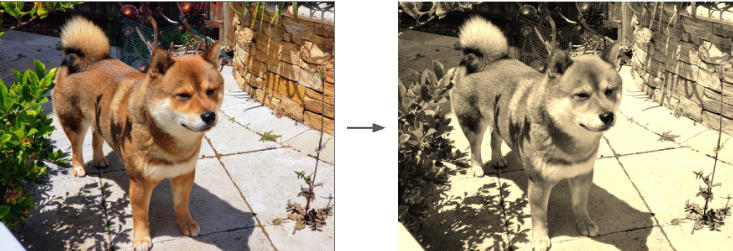



<br>

### 数学形式

从数学角度看，Sepia 风格可以看作一次**线性的颜色变换**。
将每个像素的颜色表示为一个 **RGB 列向量**：

$$
\mathbf{c} =
\begin{bmatrix}
R \\
G \\
B
\end{bmatrix}
$$

Sepia 转换可以写成矩阵乘法：

$$
\mathbf{c}' = M \mathbf{c}
$$

其中颜色变换矩阵 \( M \) 为：

$$
M =
\begin{bmatrix}
0.393 & 0.769 & 0.189 \\
0.349 & 0.686 & 0.168 \\
0.272 & 0.534 & 0.131
\end{bmatrix}
$$

该矩阵通过对 RGB 三个通道进行线性组合，将原始颜色映射到 Sepia 风格的颜色空间。

<br>

### 问题

如何用 NumPy 将一张 `(H, W, C)` 格式的图片转换成 Sepia 风格？

### 准备工作

In [ ]:
# 读取、展示原图:
image = read_image()
display_image(image)

# 拿到 H, W, C
H, W, C = image.shape

# 定义 M 矩阵:
M = np.array([
    [0.393, 0.769, 0.189],
    [0.349, 0.686, 0.168],
    [0.272, 0.534, 0.131],
], dtype=np.float32)

### 写法1：把颜色当作列向量

按照公式里的写法，把图片 reshape 成 `(H, W, 3, 1)`，把 `M` reshape 成 `(1, 1, 3, 3)`，然后让 `M` 乘在左边。


In [ ]:
# 准备数据:
image_col = image.reshape(H, W, 3, 1)
mat_left = M.reshape(1, 1, 3, 3)

# 矩阵乘法:
image_sepia = mat_left @ image_col  # Shape: (H, W, 3, 1)

# Reshape:
image_sepia = image_sepia.reshape(H, W, 3)

# 后处理、展示图片:
image_sepia = np.clip(image_sepia, 0, 255).astype(np.uint8)
display_image(image_sepia)

### 写法2：继续把颜色当作行向量

继续把颜色看作行向量，然后在右边乘 `M.T`。

In [ ]:
# 准备矩阵:
image_row = image.reshape(H, W, 1, 3)
mat_right = M.T.reshape(1, 1, 3, 3)

# 矩阵乘法:
image_sepia = image_row @ mat_right

# Reshape:
image_sepia = image_sepia.reshape(H, W, 3)

# 后处理、展示:
image_sepia = np.clip(image_sepia, 0, 255).astype(np.uint8)
display_image(image_sepia)

### 写法3：直接在 `(H, W, 3)` 上右乘 `M.T`

如果只是想让最后一维的颜色向量统一做变换，其实连 `(H, W, 1, 3)` 这一步 reshape 也可以省掉。


In [ ]:
# 准备矩阵:
mat_right = M.T.reshape(1, 3, 3)

# 确认形状:
print(f"{image.shape     = }")
print(f"{mat_right.shape = }")

# 矩阵乘法:
image_sepia = image @ mat_right

# 后处理、展示:
image_sepia = np.clip(image_sepia, 0, 255).astype(np.uint8)
display_image(image_sepia)

# 思考题：极简版的卷积操作

在图像处理中，卷积操作 `convolution` 指的是：

- 用一个固定大小的 `kernel`
- 与图像中的每一个局部 `patch` 做内积
- 生成一张新的图像。

<video controls playsinline style="width:100%; height:auto;" src="..."></video>


现在，我们尝试实现一个极简版的卷积操作，让我们假设：

- 输入图像是个二维数组，即黑白图像
- `kernel` 的尺寸是 `2×2`
- 卷积的 `stride` 为 `2`

<table style="width:100%; table-layout:fixed;">
  <tr>
    <td align="center" style="width:60%;"><b>输入图像（红色通道）</b></td>
    <td align="center" style="width:10%;"></td>
    <td align="center" style="width:30%;"><b>卷积结果</b></td>
  </tr>
  <tr>
    <td align="center" valign="middle" style="width:60%;">
      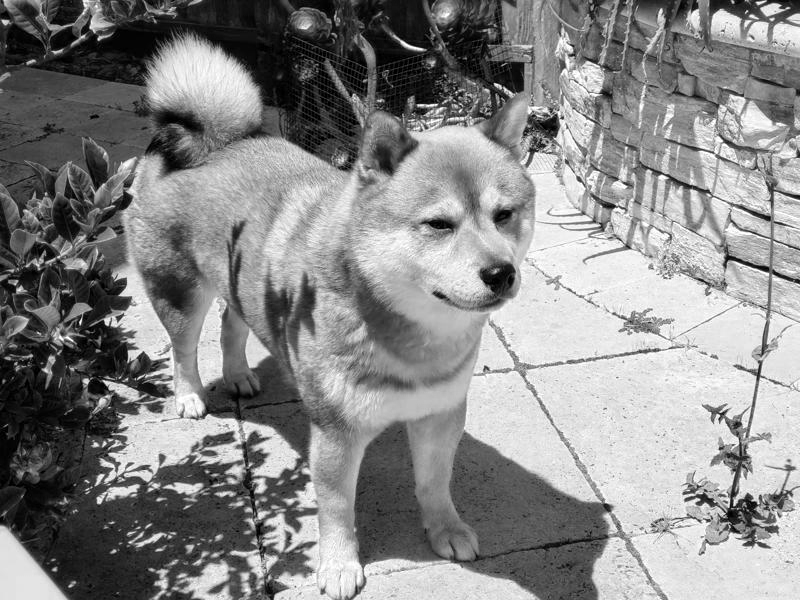<br>
      <code>800 × 600</code>
    </td>
    <td align="center" valign="middle" style="width:10%;">
      <div style="font-size:52px;text-align:center;">&#8594;</div>
    </td>
    <td align="center" valign="middle" style="width:30%;">
      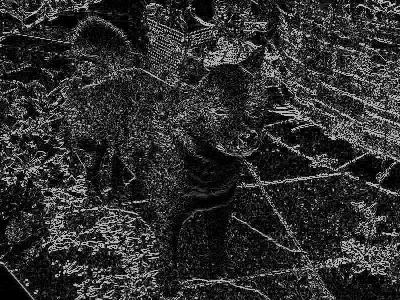<br>
      <code>400 × 300</code>
    </td>
  </tr>
</table>


**提示:**
- 只使用 `reshape`、`transpose` 和 `矩阵乘法`
- Kernel 定义: $\begin{bmatrix} 0.75 & 0.75 \\ -0.75 & -0.75 \end{bmatrix}$